## Pulseq vs Ismrmrd

Demonstrating the difference between extracting data using Pulseq with ISMRMRD, and comparing it to Pulseq with shifted trajectories and the updated ISMRMRD function.

### Import and function definition

In [7]:
# Import
import torch
import matplotlib.pyplot as plt
import mrpro

from mrpro.data  import KData, KTrajectory
from mrpro.data.traj_calculators import KTrajectoryPulseq, KTrajectoryIsmrmrd


h5_path = '/data/bouill01/PTBSequences/PTBSequences/ismrmrd/20240823_spiral_2D_256mm_472k0_32interleaves_golden_angle_vds/meas_MID00056_FID06902_20240731_spiral_2D_256mm_472k0_32interleaves_golden_angle_vds_with_traj.h5'
seq_path = '/data/bouill01/PTBSequences/PTBSequences/ismrmrd/20240823_spiral_2D_256mm_472k0_32interleaves_golden_angle_vds/20240823_spiral_2D_256mm_472k0_32interleaves_golden_angle_vds.seq'

h5_path_old = '/data/bouill01/PTBSequences/PTBSequences/31july/20240731_spiral_2D_256mm_472k0_32interleaves_golden_angle_vds/meas_MID00056_FID06902_20240731_spiral_2D_256mm_472k0_32interleaves_golden_angle_vds_with_traj.h5'
seq_path_old = '/data/bouill01/PTBSequences/PTBSequences/31july/20240731_spiral_2D_256mm_472k0_32interleaves_golden_angle_vds/20240731_spiral_2D_256mm_472k0_32interleaves_golden_angle_vds.seq'


In [8]:
def shift_k_space_trajectory(kdatapuls):
    # Extract k-space trajectory from kdatapuls
    ky_pulseq = kdatapuls.traj.ky
    kx_pulseq = kdatapuls.traj.kx
    kz_pulseq = kdatapuls.traj.kz

    # Number of indices
    num_indices = ky_pulseq.shape[2]

    # Initialize lists to store shifted trajectories
    shifted_ky = ky_pulseq.clone()
    shifted_kx = kx_pulseq.clone()

    # Loop to apply the shift to each index
    for i in range(num_indices-1):
        # Calculate the shift for the current index
        shifted_ky[:,:,i,:] -= ky_pulseq[:,:,i,0]
        shifted_kx[:,:,i,:] -= kx_pulseq[:,:,i,0]

    # Create shifted KTrajectory object
    shifted_traj = KTrajectory(kx=shifted_kx, ky=shifted_ky, kz=kz_pulseq)
    # Create shifted KData object
    shifted_kdatapuls = KData(data=kdatapuls.data, traj=shifted_traj, header=kdatapuls.header)

    return shifted_kdatapuls

### New ISMRMRD VS Old ISMRMRD VS Pulseq VS shifted Pulseq

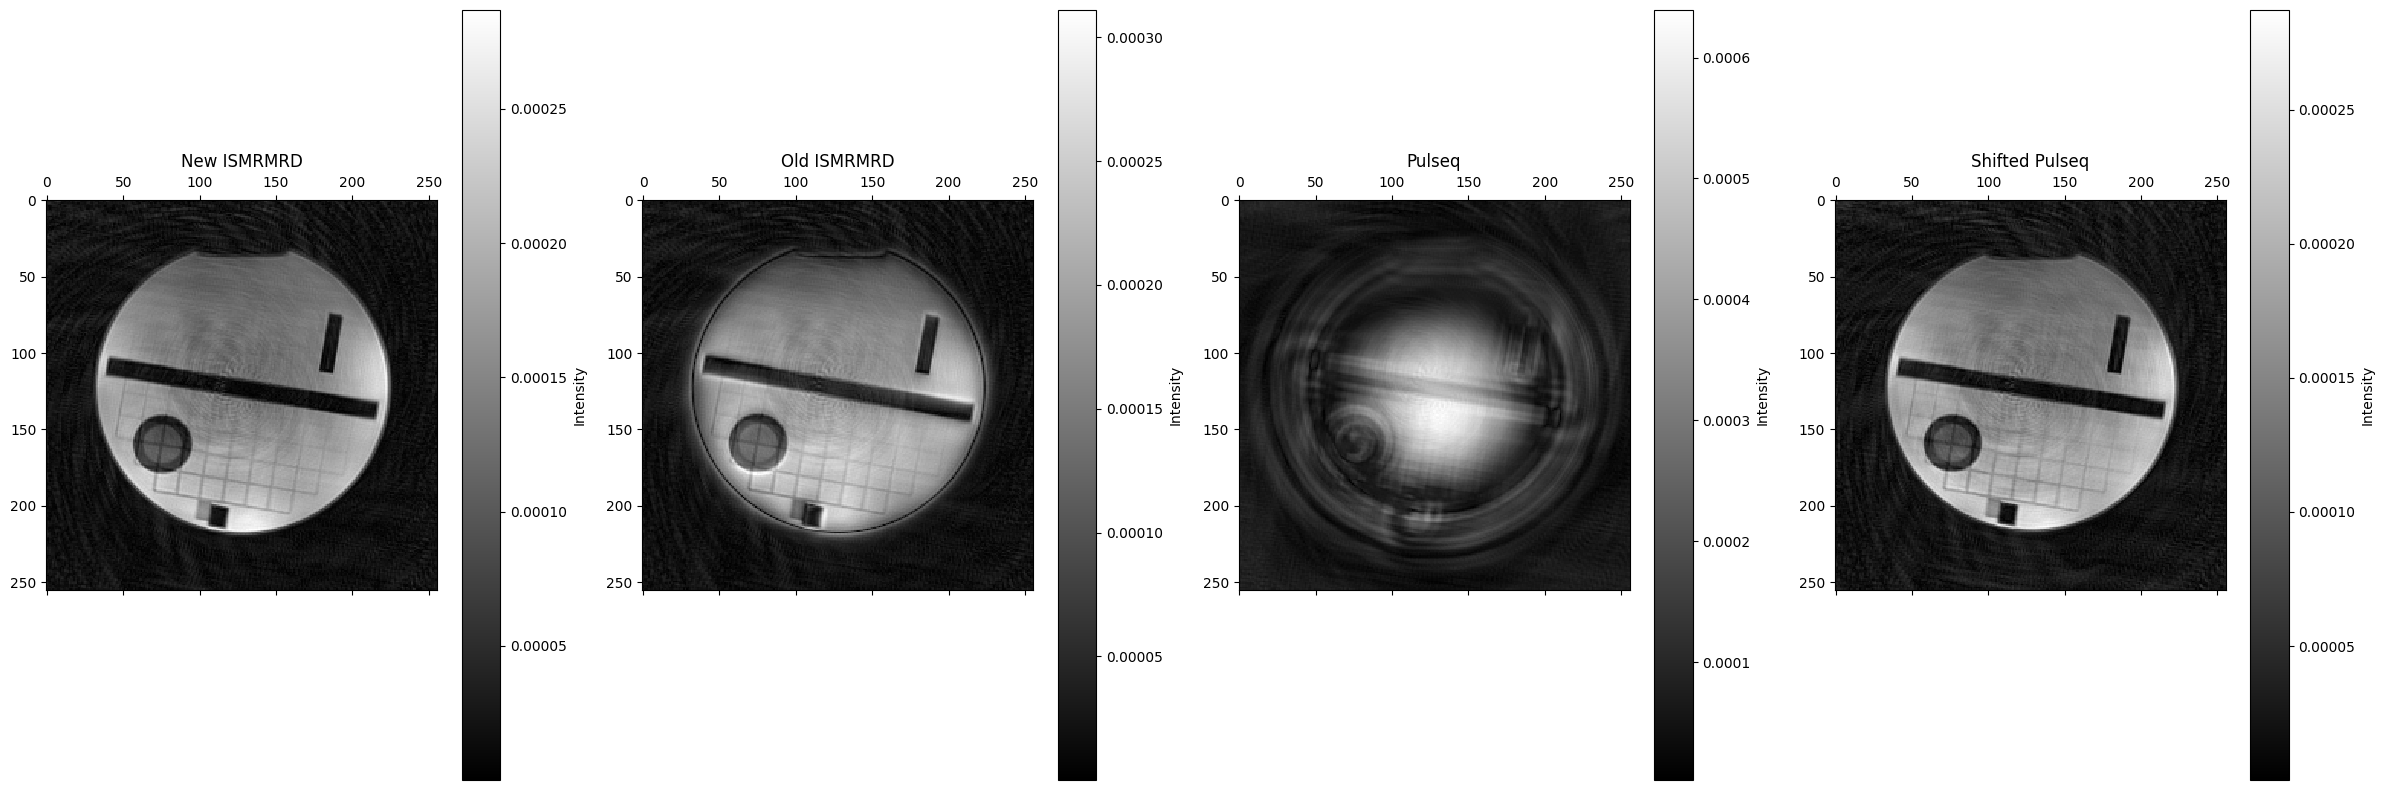

In [9]:
# Load and reconstruct

kdata_ismrmrd = KData.from_file(h5_path_old, KTrajectoryIsmrmrd())
reconstruction_ismrmrd = mrpro.algorithms.reconstruction.DirectReconstruction.from_kdata(kdata_ismrmrd)
img_ismrmrd = reconstruction_ismrmrd(kdata_ismrmrd).data

kdata_ismrmrd_aft = KData.from_file(h5_path, KTrajectoryIsmrmrd())
reconstruction_ismrmrd_aft = mrpro.algorithms.reconstruction.DirectReconstruction.from_kdata(kdata_ismrmrd_aft)
img_ismrmrd_aft = reconstruction_ismrmrd_aft(kdata_ismrmrd_aft).data

kdata_puls = KData.from_file(h5_path, KTrajectoryPulseq(seq_path=seq_path))
reco_puls = mrpro.algorithms.reconstruction.DirectReconstruction.from_kdata(kdata_puls)
img_puls = reco_puls(kdata_puls).data

shift_puls = shift_k_space_trajectory(kdatapuls=kdata_puls)
reco_shift = mrpro.algorithms.reconstruction.DirectReconstruction.from_kdata(shift_puls)
img_shift = reco_shift(shift_puls).data



fig, axes = plt.subplots(1, 4, figsize=(24, 8))

ax1 = axes[0]
cax1 = ax1.matshow(torch.abs(img_ismrmrd_aft).squeeze(), cmap='gray')
ax1.set_title('New ISMRMRD')
fig.colorbar(cax1, ax=ax1, orientation='vertical', label='Intensity')

ax2 = axes[2]
cax2 = ax2.matshow(torch.abs(img_puls).squeeze(), cmap='gray')
ax2.set_title('Pulseq')
fig.colorbar(cax2, ax=ax2, orientation='vertical', label='Intensity')

ax3 = axes[3]
cax3 = ax3.matshow(img_shift.squeeze().abs(), cmap='gray')
ax3.set_title('Shifted Pulseq')
fig.colorbar(cax3, ax=ax3, orientation='vertical', label='Intensity')

ax4 = axes[1]
cax4 = ax4.matshow(img_ismrmrd.squeeze().abs(), cmap='gray')
ax4.set_title('Old ISMRMRD')
fig.colorbar(cax4, ax=ax4, orientation='vertical', label='Intensity')
plt.tight_layout()
plt.show()

### Trajectories and Errors Display

Calculating for us_idx 1: tensor([[ 0, 31]])
traj_ky_0_0 = 0.0
traj_kx_0_0 = 0.0
traj_ky_127_0 = 1.064836859703064
traj_kx_127_0 = -0.6837218999862671
shifted_ky_0_0 = 0.0
shifted_kx_0_0 = 0.0
shifted_ky_127_0 = 0.0
shifted_kx_127_0 = 0.0
irmrmrd_ky_0_0 = -1.0045235285360832e-05
irmrmrd_kx_0_0 = -0.0035763573832809925
irmrmrd_ky_127_0 = 0.0030027376487851143
irmrmrd_kx_127_0 = -0.0019426783546805382


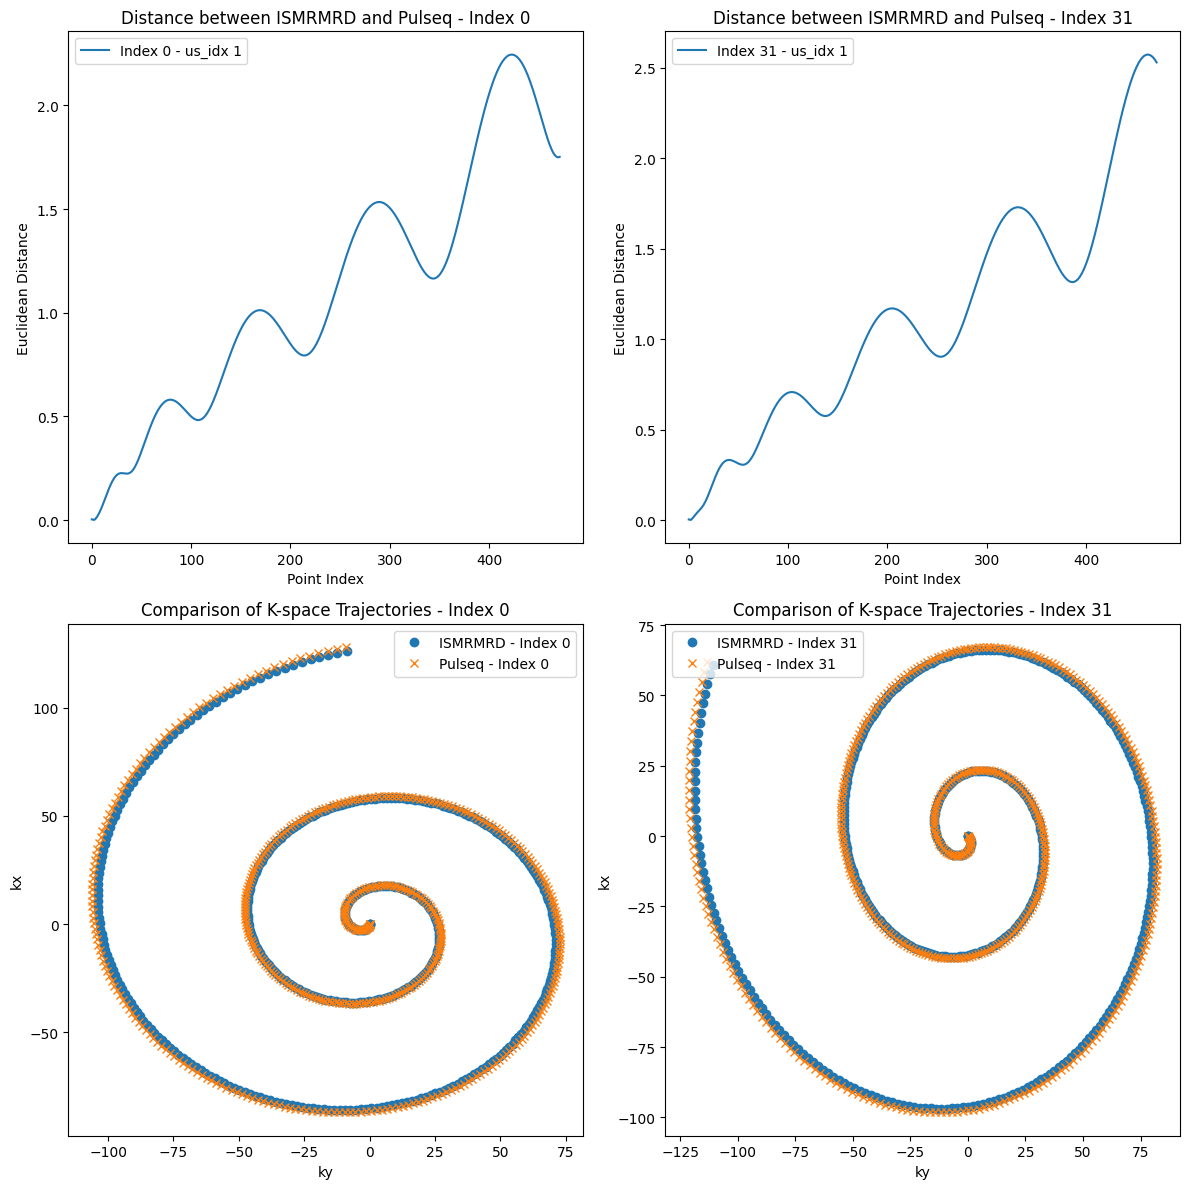

In [10]:
import torch
from mrpro.data import KData
from mrpro.data.traj_calculators import KTrajectoryIsmrmrd, KTrajectoryPulseq
import matplotlib.pyplot as plt

# Load data
kdata_ismrmrd = KData.from_file(h5_path, KTrajectoryIsmrmrd())

kdata_pulseq = KData.from_file(h5_path, KTrajectoryPulseq(seq_path=seq_path))
kdata_pulseq = shift_k_space_trajectory(kdatapuls=kdata_pulseq)

# Define values to compare for us_idx
us_idx_values = [torch.arange(0, 32, 31)[None, :]]


fig, axs = plt.subplots(2, 2, figsize=(12, 12))

for i, us_idx in enumerate(us_idx_values):
    print(f"Calculating for us_idx {i+1}:", us_idx)
    
    # Split k-space data into other dimensions based on undersampling indices
    kdata_us_ismrmrd = kdata_ismrmrd.split_k1_into_other(us_idx, other_label='repetition')
    kdata_us_pulseq = kdata_pulseq.split_k1_into_other(us_idx, other_label='repetition')
    
    # Extract the trajectories for index 0 and 127
    traj_ky_0 = kdata_us_pulseq.traj.ky[:, :, 0, :]
    traj_ky_127 = kdata_us_pulseq.traj.ky[:, :, -1, :]
    traj_kx_0 = kdata_us_pulseq.traj.kx[:, :, 0, :]
    traj_kx_127 = kdata_us_pulseq.traj.kx[:, :, -1, :]
    
    print(f'traj_ky_0_0 = {traj_ky_0[0,0,0]}')
    print(f'traj_kx_0_0 = {traj_kx_0[0,0,0]}')
    print(f'traj_ky_127_0 = {traj_ky_127[0,0,0]}')
    print(f'traj_kx_127_0 = {traj_kx_127[0,0,0]}')
    
    # Shift the k-space trajectories for index 0
    shifted_ky_pulseq_0 = traj_ky_0 - traj_ky_0[:,:, 0, None]
    shifted_kx_pulseq_0 = traj_kx_0 - traj_kx_0[:,:, 0, None]

    # Shift the k-space trajectories for index 127
    shifted_ky_pulseq_127 = traj_ky_127 - traj_ky_127[:,:,0, None]
    shifted_kx_pulseq_127 = traj_kx_127 - traj_kx_127[:,:,0, None]

    print(f'shifted_ky_0_0 = {shifted_ky_pulseq_0[0,0,0]}')
    print(f'shifted_kx_0_0 = {shifted_kx_pulseq_0[0,0,0]}')
    print(f'shifted_ky_127_0 = {shifted_ky_pulseq_127[0,0,0]}')
    print(f'shifted_kx_127_0 = {shifted_kx_pulseq_127[0,0,0]}')

    # Combine the shifted trajectories into one tensor
    traj_ky_shiftpulseq = torch.cat((shifted_ky_pulseq_0.unsqueeze(2), shifted_ky_pulseq_127.unsqueeze(2)), dim=2)
    traj_kx_shiftpulseq = torch.cat((shifted_kx_pulseq_0.unsqueeze(2), shifted_kx_pulseq_127.unsqueeze(2)), dim=2)
    
    traj_ky_ismrmrd = kdata_us_ismrmrd.traj.ky
    traj_kx_ismrmrd = kdata_us_ismrmrd.traj.kx

    print(f'irmrmrd_ky_0_0 = {traj_ky_ismrmrd[0,0,0,0]}')
    print(f'irmrmrd_kx_0_0 = {traj_kx_ismrmrd[0,0,0,0]}')
    print(f'irmrmrd_ky_127_0 = {traj_ky_ismrmrd[0,0,1,0]}')
    print(f'irmrmrd_kx_127_0 = {traj_kx_ismrmrd[0,0,1,0]}')
    
    # Calculate the difference between Pulseq and ISMRMRD trajectories
    diff_ky = traj_ky_shiftpulseq - traj_ky_ismrmrd
    diff_kx = traj_kx_shiftpulseq - traj_kx_ismrmrd

    # Calculate the Euclidean distance between the trajectories
    distance = torch.sqrt(diff_ky**2 + diff_kx**2).cpu().numpy()

    axs[0, 0].plot(distance[:, :, 0].flatten(), label=f'Index 0 - us_idx {i+1}')
    axs[0, 0].set_xlabel('Point Index')
    axs[0, 0].set_ylabel('Euclidean Distance')
    axs[0, 0].set_title(f'Distance between ISMRMRD and Pulseq - Index 0')
    axs[0, 0].legend()

    axs[0, 1].plot(distance[:, :, 1].flatten(), label=f'Index 31 - us_idx {i+1}')
    axs[0, 1].set_xlabel('Point Index')
    axs[0, 1].set_ylabel('Euclidean Distance')
    axs[0, 1].set_title(f'Distance between ISMRMRD and Pulseq - Index 31')
    axs[0, 1].legend()

    axs[1, 0].plot(traj_ky_ismrmrd[:, :, 0].cpu().numpy().flatten(), traj_kx_ismrmrd[:, :, 0].cpu().numpy().flatten(), 'o', label=f'ISMRMRD - Index 0')
    axs[1, 0].plot(traj_ky_shiftpulseq[:, :, 0].cpu().numpy().flatten(), traj_kx_shiftpulseq[:, :, 0].cpu().numpy().flatten(), 'x', label=f'Pulseq - Index 0')
    axs[1, 0].set_xlabel('ky')
    axs[1, 0].set_ylabel('kx')
    axs[1, 0].set_title(f'Comparison of K-space Trajectories - Index 0')
    axs[1, 0].legend()

    axs[1, 1].plot(traj_ky_ismrmrd[:, :, -1].cpu().numpy().flatten(), traj_kx_ismrmrd[:, :, -1].cpu().numpy().flatten(), 'o', label=f'ISMRMRD - Index 31')
    axs[1, 1].plot(traj_ky_shiftpulseq[:, :, 1].cpu().numpy().flatten(), traj_kx_shiftpulseq[:, :, 1].cpu().numpy().flatten(), 'x', label=f'Pulseq - Index 31')
    axs[1, 1].set_xlabel('ky')
    axs[1, 1].set_ylabel('kx')
    axs[1, 1].set_title(f'Comparison of K-space Trajectories - Index 31')
    axs[1, 1].legend()

plt.tight_layout()
plt.show()
